In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import mode

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

In [3]:
class KMeansScratch:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):

        # Random centroid initialization
        random_idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):

            # Assign clusters
            distances = np.linalg.norm(
                X[:, np.newaxis] - self.centroids,
                axis=2
            )

            self.labels = np.argmin(distances, axis=1)

            # Store old centroids
            old_centroids = self.centroids.copy()

            # Recompute centroids
            self.centroids = np.array([
                X[self.labels == i].mean(axis=0)
                for i in range(self.k)
            ])

            # Check convergence
            if np.allclose(old_centroids, self.centroids):
                break

        return self

In [4]:
manual_kmeans = KMeansScratch(k=3)
manual_kmeans.fit(X)

manual_labels = manual_kmeans.labels
manual_centroids = manual_kmeans.centroids

In [5]:
sklearn_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

sklearn_labels = sklearn_kmeans.fit_predict(X)
sklearn_centroids = sklearn_kmeans.cluster_centers_

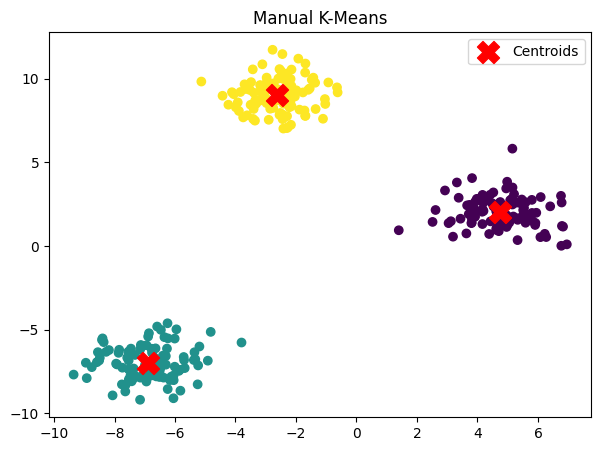

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=manual_labels,
    cmap='viridis'
)

plt.scatter(
    manual_centroids[:,0],
    manual_centroids[:,1],
    s=250,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("Manual K-Means")
plt.legend()
plt.show()


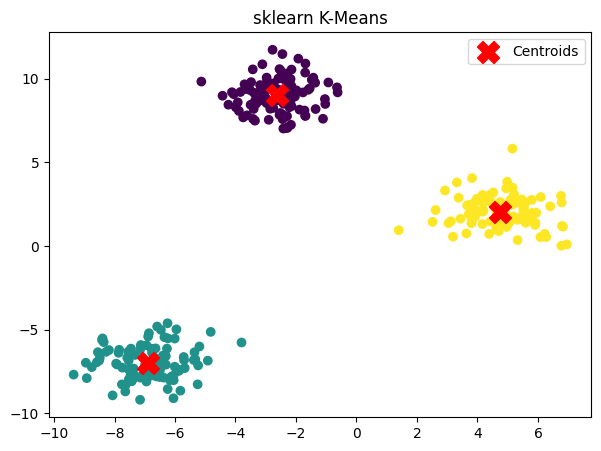

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=sklearn_labels,
    cmap='viridis'
)

plt.scatter(
    sklearn_centroids[:,0],
    sklearn_centroids[:,1],
    s=250,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("sklearn K-Means")
plt.legend()
plt.show()

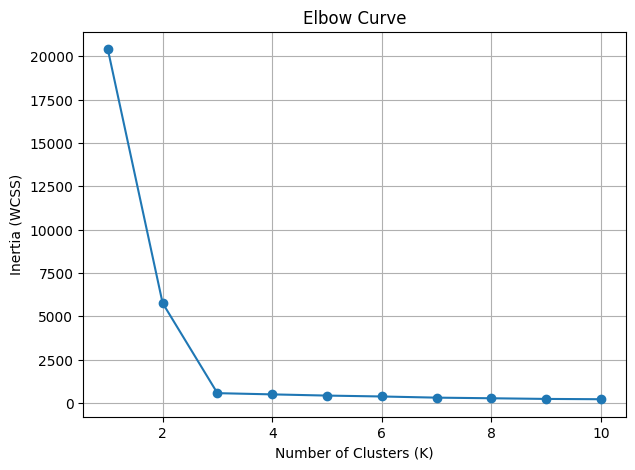

In [8]:
inertia_values = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Curve")
plt.grid(True)
plt.show()


In [9]:
manual_silhouette = silhouette_score(
    X,
    manual_labels
)

sklearn_silhouette = silhouette_score(
    X,
    sklearn_labels
)

print("Manual K-Means Silhouette Score:",
      round(manual_silhouette, 4))

print("Sklearn K-Means Silhouette Score:",
      round(sklearn_silhouette, 4))

Manual K-Means Silhouette Score: 0.848
Sklearn K-Means Silhouette Score: 0.848


In [10]:
mapping = {}

for cluster in np.unique(manual_labels):
    mask = manual_labels == cluster
    mapped_cluster = mode(
        sklearn_labels[mask],
        keepdims=True
    ).mode[0]

    mapping[cluster] = mapped_cluster

converted_manual = np.vectorize(mapping.get)(manual_labels)

agreement = np.mean(
    converted_manual == sklearn_labels
) * 100

print(f"\nCluster Assignment Agreement: {agreement:.2f}%")


Cluster Assignment Agreement: 100.00%
